In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [8]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()
df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
print(df.columns.tolist())

['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [10]:
df.columns = df.columns.str.replace(".", "_", regex=False)
print(df.columns.tolist())

['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']


#Limpieza y preparación de datos

In [11]:
# Eliminar duplicados
df = df.drop_duplicates()

# Convertir Churn a numérico
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0
})
df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")

# Convertir columnas binarias
binary_cols = [
    "customer_Partner",
    "customer_Dependents",
    "phone_PhoneService",
    "account_PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].replace({
        "Yes": 1,
        "No": 0
    })

# Convertir SeniorCitizen a numérico
df["customer_SeniorCitizen"] = pd.to_numeric(df["customer_SeniorCitizen"], errors="coerce")

# Convertir cargos a numérico
df["account_Charges_Monthly"] = pd.to_numeric(df["account_Charges_Monthly"], errors="coerce")
df["account_Charges_Total"] = pd.to_numeric(df["account_Charges_Total"], errors="coerce")

# Eliminar ID
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Eliminar nulos
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7032 non-null   float64
 1   customer_gender            7032 non-null   object 
 2   customer_SeniorCitizen     7032 non-null   int64  
 3   customer_Partner           7032 non-null   int64  
 4   customer_Dependents        7032 non-null   int64  
 5   customer_tenure            7032 non-null   int64  
 6   phone_PhoneService         7032 non-null   int64  
 7   phone_MultipleLines        7032 non-null   object 
 8   internet_InternetService   7032 non-null   object 
 9   internet_OnlineSecurity    7032 non-null   object 
 10  internet_OnlineBackup      7032 non-null   object 
 11  internet_DeviceProtection  7032 non-null   object 
 12  internet_TechSupport       7032 non-null   object 
 13  internet_StreamingTV       7032 non-null   object 
 1

/tmp/ipykernel_206/2112386567.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


## Verificar balance de clases

In [12]:
print("Conteo de clases:")
print(df["Churn"].value_counts())

print("\nPorcentaje de clases:")
print(df["Churn"].value_counts(normalize=True) * 100)

Conteo de clases:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64

Porcentaje de clases:
Churn
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


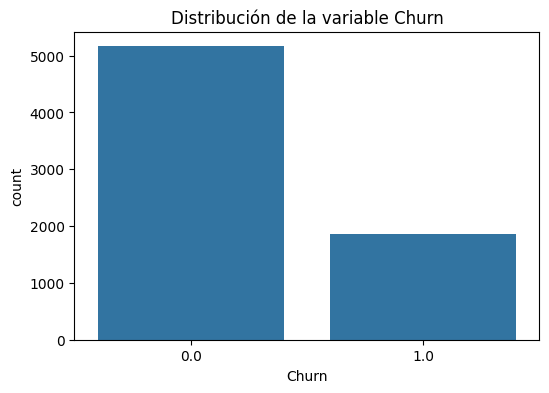

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribución de la variable Churn")
plt.show()

## Codificar variables categóricas

In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,customer_gender_Male,...,internet_TechSupport_Yes,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,1,65.6,593.30,False,...,True,False,True,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,0,59.9,542.40,True,...,False,False,False,False,True,False,False,False,False,True
2,1.0,0,0,0,4,1,1,73.9,280.85,True,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1,1,0,13,1,1,98.0,1237.85,True,...,False,False,True,False,True,False,False,False,True,False
4,1.0,1,1,0,3,1,1,83.9,267.40,False,...,True,False,True,False,False,False,False,False,False,True


# Correlación con Churn

In [17]:
corr_churn = df_encoded.corr()["Churn"].sort_values(ascending=False)
print(corr_churn)

Churn                                            1.000000
internet_InternetService_Fiber optic             0.307463
account_PaymentMethod_Electronic check           0.301455
account_Charges_Monthly                          0.192858
account_PaperlessBilling                         0.191454
customer_SeniorCitizen                           0.150541
internet_StreamingTV_Yes                         0.063254
internet_StreamingMovies_Yes                     0.060860
phone_MultipleLines_Yes                          0.040033
phone_PhoneService                               0.011691
customer_gender_Male                            -0.008545
phone_MultipleLines_No phone service            -0.011691
internet_DeviceProtection_Yes                   -0.066193
internet_OnlineBackup_Yes                       -0.082307
account_PaymentMethod_Mailed check              -0.090773
account_PaymentMethod_Credit card (automatic)   -0.134687
customer_Partner                                -0.149982
customer_Depen

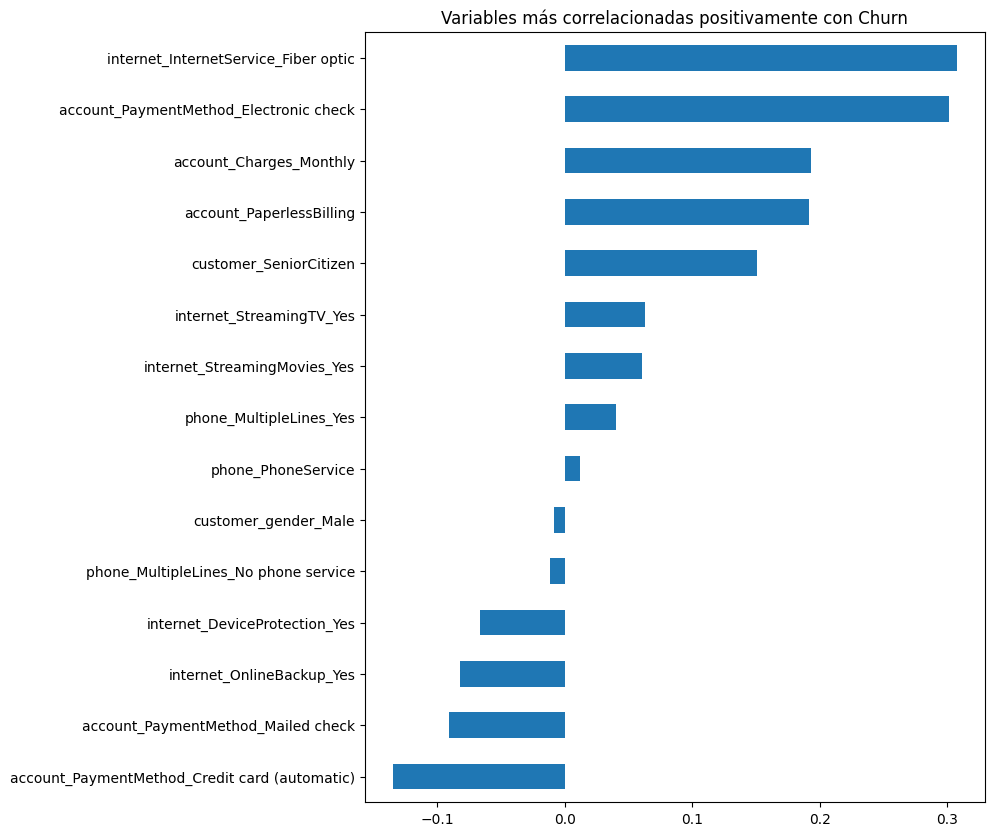

In [18]:
plt.figure(figsize=(8,10))
corr_churn.drop("Churn").sort_values().tail(15).plot(kind="barh")
plt.title("Variables más correlacionadas positivamente con Churn")
plt.show()

# Matriz de correlación

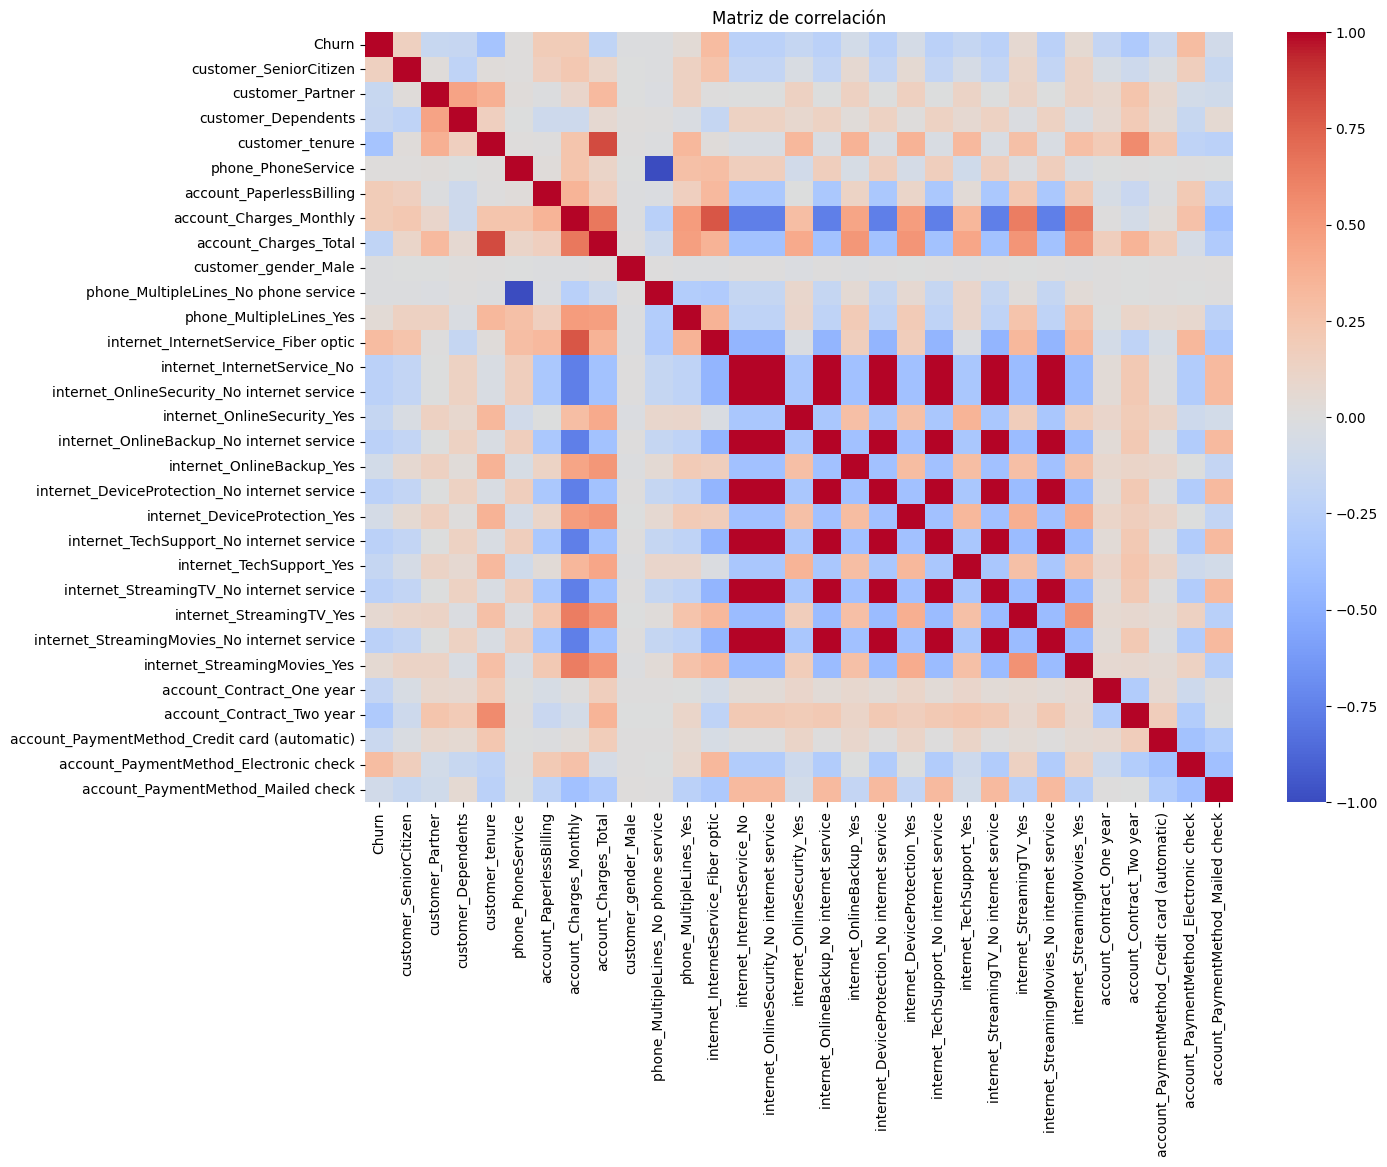

In [19]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

#Visualizaciones importantes

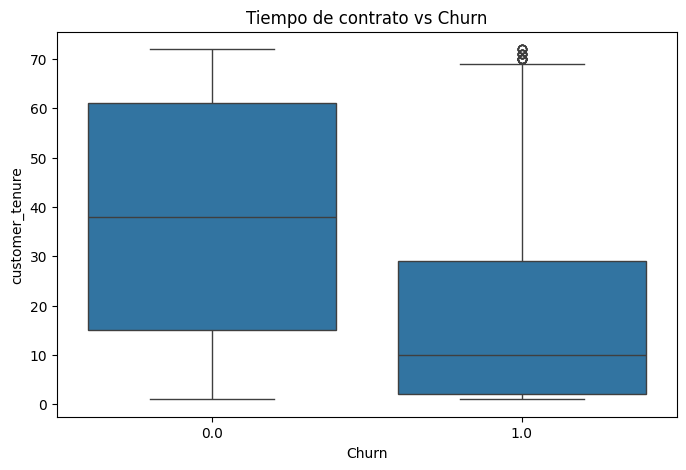

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="customer_tenure")
plt.title("Tiempo de contrato vs Churn")
plt.show()

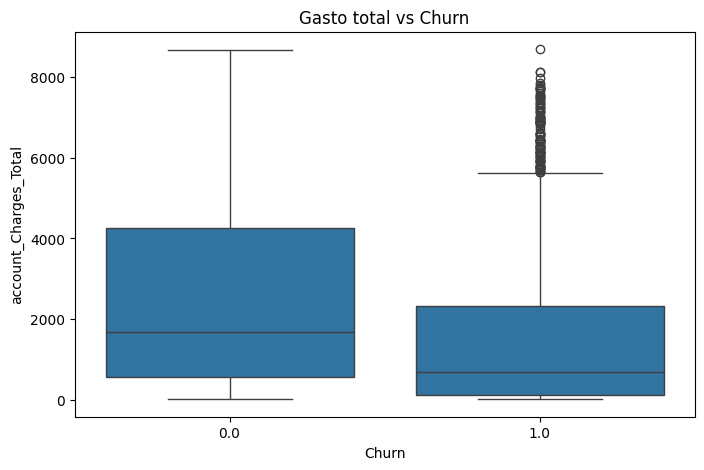

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="account_Charges_Total")
plt.title("Gasto total vs Churn")
plt.show()

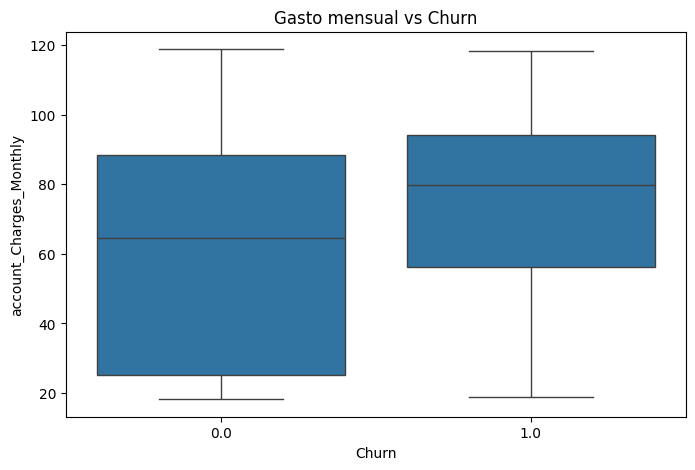

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="account_Charges_Monthly")
plt.title("Gasto mensual vs Churn")
plt.show()

# Separación de variables

In [23]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## Dividir Train y Test

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (4922, 30) (4922,)
Prueba: (2110, 30) (2110,)


# Modelo 1. Regresión logística con normalización

In [25]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

In [26]:
print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_lr))

=== Regresión Logística ===
Accuracy: 0.8033175355450237
Precision: 0.6573275862068966
Recall: 0.5436720142602496
F1-score: 0.5951219512195122

Reporte de clasificación:

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



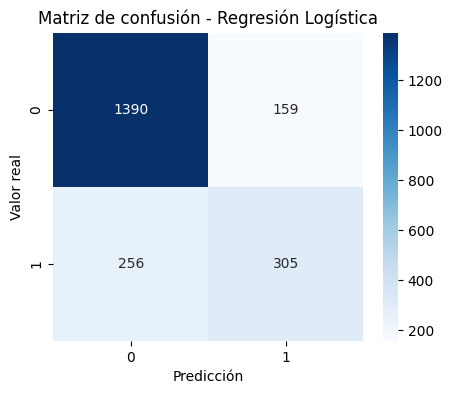

In [27]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# Modelo 2. Random Forest sin normalización

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [29]:
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7815165876777251
Precision: 0.6225490196078431
Recall: 0.45276292335115864
F1-score: 0.5242518059855521

Reporte de clasificación:

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1549
         1.0       0.62      0.45      0.52       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110



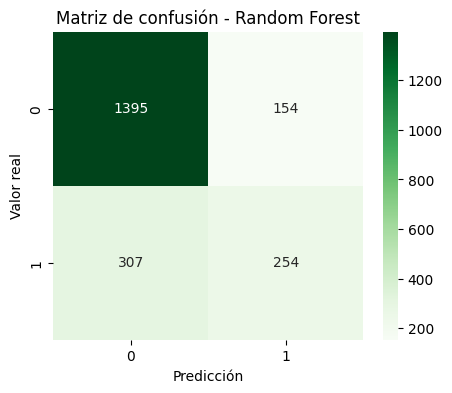

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

#Comparación modelos

In [31]:
results = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                Modelo  Accuracy  Precision    Recall  F1-score
0  Regresión Logística  0.803318   0.657328  0.543672  0.595122
1        Random Forest  0.781517   0.622549  0.452763  0.524252


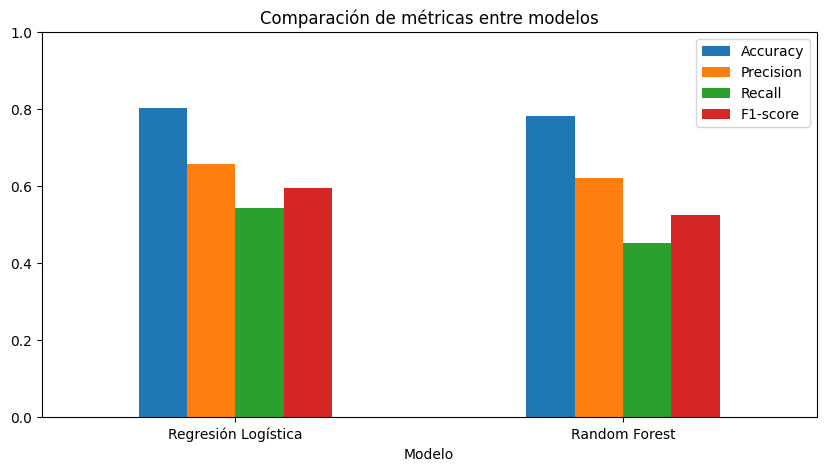

In [32]:
results.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Comparación de métricas entre modelos")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

## Revisar over/underfitting

In [33]:
train_score_lr = pipeline_lr.score(X_train, y_train)
test_score_lr = pipeline_lr.score(X_test, y_test)

print("Regresión Logística - Train Score:", train_score_lr)
print("Regresión Logística - Test Score:", test_score_lr)

Regresión Logística - Train Score: 0.8075985371800082
Regresión Logística - Test Score: 0.8033175355450237


In [34]:
train_score_rf = rf_model.score(X_train, y_train)
test_score_rf = rf_model.score(X_test, y_test)

print("Random Forest - Train Score:", train_score_rf)
print("Random Forest - Test Score:", test_score_rf)


Random Forest - Train Score: 0.9985778138967899
Random Forest - Test Score: 0.7815165876777251


#Variables mas importantes LR

In [35]:
coef_lr = pipeline_lr.named_steps["model"].coef_[0]

importance_lr = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": coef_lr
})

importance_lr["Abs_Coeficiente"] = importance_lr["Coeficiente"].abs()
importance_lr = importance_lr.sort_values("Abs_Coeficiente", ascending=False)

print(importance_lr.head(15))

                                     Variable  Coeficiente  Abs_Coeficiente
3                             customer_tenure    -1.343554         1.343554
7                       account_Charges_Total     0.626025         0.626025
11       internet_InternetService_Fiber optic     0.594341         0.594341
26                  account_Contract_Two year    -0.542835         0.542835
6                     account_Charges_Monthly    -0.510416         0.510416
25                  account_Contract_One year    -0.285491         0.285491
22                   internet_StreamingTV_Yes     0.201481         0.201481
28     account_PaymentMethod_Electronic check     0.183835         0.183835
5                    account_PaperlessBilling     0.180289         0.180289
24               internet_StreamingMovies_Yes     0.156266         0.156266
20                   internet_TechSupport_Yes    -0.149677         0.149677
10                    phone_MultipleLines_Yes     0.129529         0.129529
14          

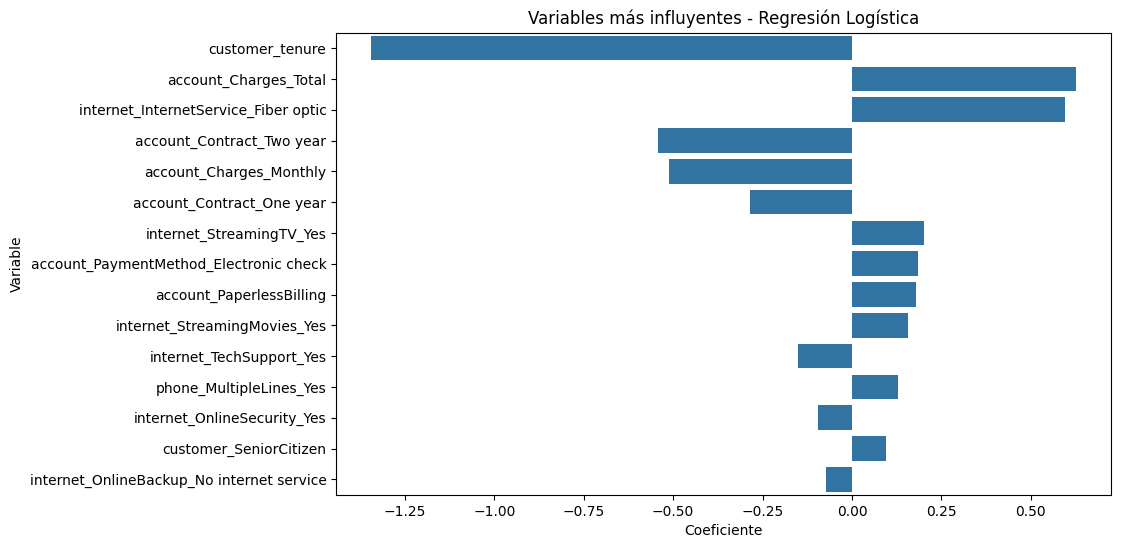

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_lr.head(15),
    x="Coeficiente",
    y="Variable"
)
plt.title("Variables más influyentes - Regresión Logística")
plt.show()

#Variables mas improtantes RF

In [37]:
importance_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values("Importancia", ascending=False)

print(importance_rf.head(15))

                                  Variable  Importancia
7                    account_Charges_Total     0.176384
3                          customer_tenure     0.164576
6                  account_Charges_Monthly     0.152809
26               account_Contract_Two year     0.054663
11    internet_InternetService_Fiber optic     0.041201
28  account_PaymentMethod_Electronic check     0.040199
25               account_Contract_One year     0.027365
8                     customer_gender_Male     0.025521
14             internet_OnlineSecurity_Yes     0.025201
20                internet_TechSupport_Yes     0.024915
5                 account_PaperlessBilling     0.024255
1                         customer_Partner     0.021613
16               internet_OnlineBackup_Yes     0.020076
2                      customer_Dependents     0.019751
0                   customer_SeniorCitizen     0.018940


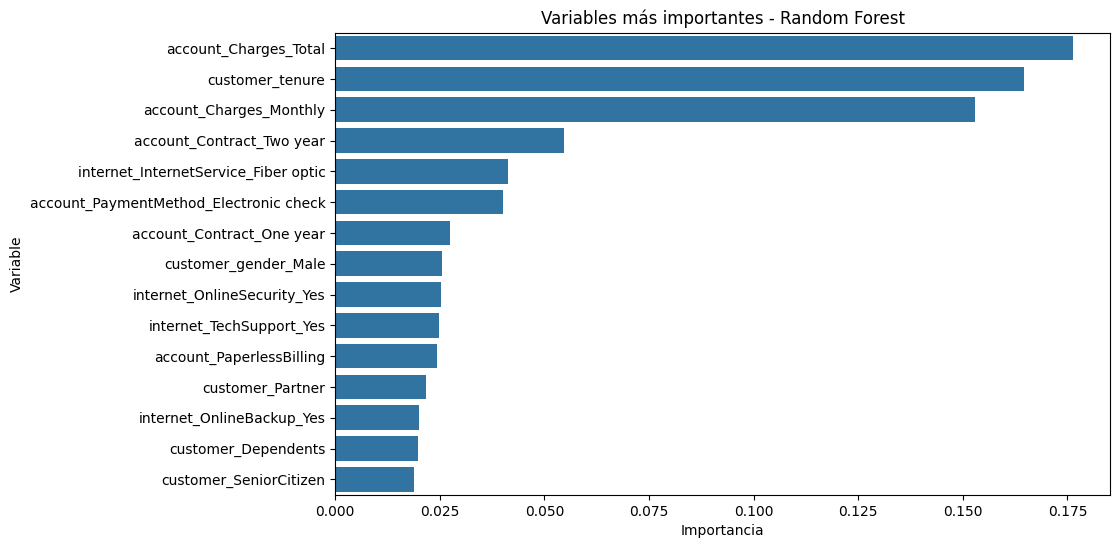

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_rf.head(15),
    x="Importancia",
    y="Variable"
)
plt.title("Variables más importantes - Random Forest")
plt.show()

#MEJOR MODELO

In [39]:
best_model = results.sort_values("F1-score", ascending=False).iloc[0]

print("Mejor modelo según F1-score:")
print(best_model)

Mejor modelo según F1-score:
Modelo       Regresión Logística
Accuracy                0.803318
Precision               0.657328
Recall                  0.543672
F1-score                0.595122
Name: 0, dtype: object


In [41]:
print("Resumen del modelado:")
print(f"- Tasa de churn en el dataset: {y.mean()*100:.2f}%")
print(f"- Mejor modelo por F1-score: {best_model['Modelo']}")
print(f"- F1-score del mejor modelo: {best_model['F1-score']:.4f}")

Resumen del modelado:
- Tasa de churn en el dataset: 26.58%
- Mejor modelo por F1-score: Regresión Logística
- F1-score del mejor modelo: 0.5951


## Informe Final – Predicción de Cancelación de Clientes (Churn)

En este análisis se desarrolló un modelo de machine learning para predecir la cancelación de clientes en Telecom X.

Primero se realizó la preparación de los datos, incluyendo limpieza, codificación de variables categóricas mediante One-Hot Encoding y eliminación de columnas irrelevantes como el identificador del cliente. Posteriormente se analizó el balance de clases, identificando que la tasa de cancelación es de aproximadamente **26.58%**, lo que indica un leve desbalance en el dataset.

Se exploraron las relaciones entre variables mediante análisis de correlación y visualizaciones. Algunas variables mostraron una relación significativa con la cancelación del servicio.

Posteriormente se entrenaron dos modelos de clasificación:

- Regresión Logística (con normalización)
- Random Forest (sin normalización)

Ambos modelos fueron evaluados utilizando múltiples métricas:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

El modelo con mejor desempeño fue **Regresión Logística**, obteniendo:

- Accuracy: 0.80
- Precision: 0.66
- Recall: 0.54
- F1-score: 0.595

Este modelo logró el mejor equilibrio entre precisión y recall para detectar clientes con riesgo de cancelación.

El análisis de importancia de variables permitió identificar los principales factores asociados a la cancelación del servicio.

## Principales factores que influyen en la cancelación

A partir del análisis de correlación y la importancia de variables de los modelos, se identificaron los siguientes factores clave asociados al churn:

### Factores que aumentan la probabilidad de cancelación

1. **InternetService_Fiber optic**
   - Clientes con fibra óptica muestran mayor probabilidad de cancelar.

2. **PaymentMethod_Electronic check**
   - Este método de pago aparece frecuentemente en clientes que cancelan.

3. **Monthly Charges altos**
   - Los clientes con cargos mensuales elevados presentan mayor churn.

4. **Paperless Billing**
   - Se observa una mayor proporción de cancelaciones entre usuarios con facturación digital.

5. **Senior Citizen**
   - Clientes mayores muestran una ligera mayor tendencia a cancelar.

---

### Factores que reducen la cancelación

1. **Tenure (tiempo como cliente)**
   - Clientes con mayor antigüedad son menos propensos a cancelar.

2. **Contratos de largo plazo**
   - Contratos de 1 o 2 años reducen significativamente la cancelación.

3. **Total Charges acumulados**
   - Clientes que han acumulado más gasto suelen permanecer más tiempo.

Estos factores permiten identificar patrones de comportamiento importantes para el negocio.

## Recomendaciones estratégicas

A partir del análisis realizado, se sugieren las siguientes estrategias para reducir la cancelación de clientes:

### 1. Incentivar contratos de largo plazo
Los clientes con contratos de 1 o 2 años presentan menor churn. Se recomienda ofrecer descuentos o beneficios para incentivar este tipo de contratos.

### 2. Revisar la experiencia del servicio de fibra óptica
Los clientes con fibra óptica presentan mayor cancelación, lo que podría indicar problemas de calidad, precio o expectativas del servicio.

### 3. Analizar el método de pago "Electronic Check"
Este método aparece frecuentemente en clientes que cancelan. Podría ser útil incentivar métodos automáticos como tarjeta o débito automático.

### 4. Estrategias de retención para clientes nuevos
Los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar. Programas de fidelización temprana pueden ayudar a reducir esta tasa.

### 5. Monitorear clientes con cargos mensuales altos
Los clientes con facturación elevada presentan mayor churn. Se pueden ofrecer planes personalizados o promociones para reducir el riesgo de cancelación.

Estas estrategias permitirían a Telecom X anticipar la pérdida de clientes y mejorar la retención.